# MAP 1 - Funciones Vectoriales - MK8 Mario Circuit  - Matemática 4 (308)

# 0. Introducción.

En este MAP, nos enfocaremos en utilizar las *funciones vectoriales* para modelar la consturcción de pistas.En esta segunda parte trabajaremos directamente *a partir de las funciones vectoriales* que se obtuvieron en la parte 1 y en un modelo alternativo generado por la IA.

### Objetivos
1. Definir múltiples funciones vectoriales (tramos) y sus intervalos.
2. Generar puntos desde las funciones y unirlos en un único modelo.
3. Visualizar la curva en 3D.
4. Realizar análisis físico: velocidad, aceleración, componentes tangencial y normal, curvatura, planos osculador y normal, circunferencia osculatriz.
5. Simular movimiento sobre la curva (animación interactiva) y mostrar gráficas de velocidad y aceleración.
6. Sugerir mejoras de precisión si se proporcionan datos reales.

**Nota:** Este notebook contiene celdas con funciones vacías para que puedan completarlas.

## Recomendaciones de Liberias
- Python 3.10+.
- Librerías: `numpy`, `pandas`, `matplotlib`, `plotly`, `scipy`, `sympy`.
- Opcional: `opencv-python` (solo si desean procesar imágenes).

Instalación (si es necesario):

```bash
pip install numpy pandas matplotlib plotly scipy sympy opencv-python
```

Se recomienda abrir el notebook en JupyterLab/Jupyter Notebook o en Google Colab.

In [1]:
# === Librerías comunes ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter
import sympy as sp
from IPython.display import display
plt.style.use('seaborn-v0_8')


# Parte 2 - Explorando a Fondo

Utilice **Google Colab** u otro entorno similar (consulte la Sección 5) para trabajar con el Notebook de Python adjunto en la asignación MAP 1, disponible en el portal GES del curso. Emplee cualquier herramienta de **inteligencia artificial (IA)** (ver Sección 5) para modificar y complementar dicho Notebook. Tome en cuenta que, cada consulta a la IA debe ser **documentada** en su reporte con un **screenshot** del prompt y la respuesta obtenida, explicando cómo se utilizó. En el Notebook, desarrolle cada uno de los puntos que se detallan a continuación.

$1.$ Agregue el código de su modelo matemático implementado en la Parte 1. Consulte a la IA sobre posibles mejoras y documente el resultado.

In [2]:
############################ AGREGUE SU IMPLEMENTACIÓN EN CÓDIGO EN ESTA PARTE ###########################

t = sp.symbols('t', real=True)

#Documento modificado de modelo matemático generado por CalcPlot3D.
#Utilicé Claude para convertir el modelo de CalcPlot a uno que pueda usar nuestras herramientas
curvas_def = {
    'r1': {
        'x': 25 * sp.cos(t),
        'y': 25 * sp.sin(t) + 25,
        'z': (10 / sp.pi) * t,
        'tmin': 0,
        'tmax': sp.pi,
        'tSteps': 500,
        'color': 'red',
    },
    'r2': {
        'x': sp.Integer(-25),
        'y': t,
        'z': 0.01 * t**2 - 0.0055556 * t + 3.8889,
        'tmin': -20,
        'tmax': 25,
        'tSteps': 500,
        'color': 'blue',
    },
    'r3': {
        'x': -25 * sp.cos(t),
        'y': -25 * sp.sin(t) - 20,
        'z': -(12 / (7 * sp.pi)) * t + 8,
        'tmin': 0,
        'tmax': sp.Rational(7, 6) * sp.pi,
        'tSteps': 800,
        'color': 'darkgreen',
    },
    'r4': {
        'x': 0.04 * t**2 + 0.091429 * t + 20.00857,
        'y': t,
        'z': sp.Integer(6),
        'tmin': -7.50,
        'tmax': 10,
        'tSteps': 400,
        'color': 'darkred',
    },
    'r5': {
        'x': sp.Integer(25),
        'y': 10 + 15 * t,
        'z': 6 - 6 * t,
        'tmin': 0,
        'tmax': 1,
        'tSteps': 200,
        'color': 'darkblue',
    },
}




############################################

$2.$ Grafique  en Python su modelo matemático con una animación que simule el movimiento del carro a lo largo de la pista.

In [3]:
############################ AGREGUE SU IMPLEMENTACIÓN EN CÓDIGO EN ESTA PARTE ###########################

# Preparación de la curva
class CurvaParametrica:
    """Modelo r(t) = (x(t), y(t), z(t)) con cinemática asociada."""

    def __init__(self, nombre, x_expr, y_expr, z_expr, tmin, tmax, tSteps, color):
        self.nombre = nombre
        self.color = color
        self.tmin = float(tmin)
        self.tmax = float(tmax)
        self.tSteps = tSteps

        # Vector posición simbólico
        self.r = sp.Matrix([x_expr, y_expr, z_expr])

        # Derivadas simbólicas: velocidad y aceleración
        self.v = self.r.diff(t)          # r'(t)  -> velocidad
        self.a = self.v.diff(t)          # r''(t) -> aceleración

        # Rapidez |r'(t)|
        self.rapidez = sp.sqrt(sum(comp**2 for comp in self.v))

        # Curvatura kappa(t) = |r' x r''| / |r'|^3  (fórmula estándar)
        cross = self.v.cross(self.a)
        norm_cross = sp.sqrt(sum(c**2 for c in cross))
        self.curvatura = norm_cross / self.rapidez**3

        # Funciones numéricas rápidas (numpy) a partir de las expresiones
        self._fx = sp.lambdify(t, x_expr, 'numpy')
        self._fy = sp.lambdify(t, y_expr, 'numpy')
        self._fz = sp.lambdify(t, z_expr, 'numpy')
        self._fvx = sp.lambdify(t, self.v[0], 'numpy')
        self._fvy = sp.lambdify(t, self.v[1], 'numpy')
        self._fvz = sp.lambdify(t, self.v[2], 'numpy')
        self._frapidez = sp.lambdify(t, self.rapidez, 'numpy')
        self._fcurvatura = sp.lambdify(t, self.curvatura, 'numpy')

    def evaluar(self):
        """Devuelve un DataFrame con posición, velocidad, rapidez y curvatura."""
        ts = np.linspace(self.tmin, self.tmax, self.tSteps)

        x = np.full_like(ts, self._fx(ts)) if np.isscalar(self._fx(ts)) else self._fx(ts)
        y = np.full_like(ts, self._fy(ts)) if np.isscalar(self._fy(ts)) else self._fy(ts)
        z = np.full_like(ts, self._fz(ts)) if np.isscalar(self._fz(ts)) else self._fz(ts)

        vx = np.full_like(ts, self._fvx(ts)) if np.isscalar(self._fvx(ts)) else self._fvx(ts)
        vy = np.full_like(ts, self._fvy(ts)) if np.isscalar(self._fvy(ts)) else self._fvy(ts)
        vz = np.full_like(ts, self._fvz(ts)) if np.isscalar(self._fvz(ts)) else self._fvz(ts)

        rapidez = self._frapidez(ts)
        rapidez = np.full_like(ts, rapidez) if np.isscalar(rapidez) else rapidez

        try:
            curvatura = self._fcurvatura(ts)
            curvatura = np.full_like(ts, curvatura) if np.isscalar(curvatura) else curvatura
        except ZeroDivisionError:
            curvatura = np.full_like(ts, np.nan)

        df = pd.DataFrame({
            't': ts,
            'x': x, 'y': y, 'z': z,
            'vx': vx, 'vy': vy, 'vz': vz,
            'rapidez': rapidez,
            'curvatura': curvatura,
            'curva': self.nombre,
        })
        return df

    def resumen_simbolico(self):
        print(f"--- {self.nombre} ---")
        print("r(t)  =", tuple(self.r))
        print("r'(t) =", tuple(self.v))
        print("r''(t)=", tuple(self.a))
        print("|r'(t)| =", sp.simplify(self.rapidez))
        print()

    def longitud_arco(self):
        """
        Longitud de arco:  L = ∫_{tmin}^{tmax} |r'(t)| dt

        Primero intenta resolver la integral de forma simbólica (exacta) con
        sympy; si la expresión no tiene antiderivada elemental o sympy no
        logra evaluarla en el intervalo, recurre a integración numérica
        (cuadratura adaptativa) con scipy.integrate.quad.
        Devuelve (L, exacta: bool).
        """
        # --- Intento simbólico ---
        try:
            L_sym = sp.integrate(self.rapidez, (t, self.tmin, self.tmax))
            L_val = float(sp.N(L_sym))
            if np.isfinite(L_val):
                return L_val, True
        except Exception:
            pass

        # --- Respaldo numérico (cuadratura adaptativa) ---
        f_rapidez = sp.lambdify(t, self.rapidez, 'numpy')
        L_num, _error_est = quad(f_rapidez, self.tmin, self.tmax, limit=200)
        return L_num, False

curvas = {}
dataframes = []

for nombre, d in curvas_def.items():
    c = CurvaParametrica(nombre, d['x'], d['y'], d['z'],
                          d['tmin'], d['tmax'], d['tSteps'], d['color'])
    curvas[nombre] = c
    c.resumen_simbolico()
    dataframes.append(c.evaluar())

df_total = pd.concat(dataframes, ignore_index=True)

# Suavizado opcional de la rapidez por tramo (útil si se muestrean datos ruidosos)
df_total['rapidez_suave'] = df_total.groupby('curva')['rapidez'].transform(
    lambda s: savgol_filter(s, window_length=min(51, len(s) - (1 - len(s) % 2)), polyorder=3)
    if len(s) > 51 else s
)

# Animación final

orden_recorrido = [
    ('r1', False),  # False = usar t de tmin a tmax (orden natural)
    ('r2', True),   # True  = usar t de tmax a tmin (invertido)
    ('r3', False),
    ('r4', False),
    ('r5', False),
]

tramos_ordenados = []
for nombre, invertir in orden_recorrido:
    d = df_total[df_total['curva'] == nombre].copy()
    if invertir:
        d = d.iloc[::-1].reset_index(drop=True)
    tramos_ordenados.append(d)

df_recorrido = pd.concat(tramos_ordenados, ignore_index=True)

# Down-sample a un número manejable de cuadros para la animación
N_FRAMES = 300
idx_frames = np.linspace(0, len(df_recorrido) - 1, N_FRAMES).astype(int)
df_anim = df_recorrido.iloc[idx_frames].reset_index(drop=True)

# ---------------------------------------------------------------------------
# 6a) Animación con matplotlib (se exporta como GIF)
# ---------------------------------------------------------------------------
from matplotlib.animation import FuncAnimation, PillowWriter

fig3 = plt.figure(figsize=(9, 7))
ax3 = fig3.add_subplot(111, projection='3d')

# Trayectoria completa de fondo (tenue), coloreada por tramo original
for nombre, c in curvas.items():
    d = df_total[df_total['curva'] == nombre]
    ax3.plot(d['x'], d['y'], d['z'], color=c.color, linewidth=1.5, alpha=0.5, label=nombre)

ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('z')
ax3.set_title('Simulación del movimiento del punto (sentido antihorario, inicio en r1)')
ax3.legend(loc='upper left', fontsize=8)
ax3.set_xlim(df_recorrido['x'].min() - 5, df_recorrido['x'].max() + 5)
ax3.set_ylim(df_recorrido['y'].min() - 5, df_recorrido['y'].max() + 5)
ax3.set_zlim(df_recorrido['z'].min() - 2, df_recorrido['z'].max() + 2)

# Estela (rastro recorrido) y punto móvil
estela, = ax3.plot([], [], [], color='black', linewidth=2.5)
punto, = ax3.plot([], [], [], marker='o', markersize=8, color='crimson')
texto = ax3.text2D(0.02, 0.95, '', transform=ax3.transAxes, fontsize=9)


def init_anim():
    estela.set_data([], [])
    estela.set_3d_properties([])
    punto.set_data([], [])
    punto.set_3d_properties([])
    texto.set_text('')
    return estela, punto, texto


def update_anim(frame_i):
    xs = df_anim['x'].iloc[:frame_i + 1]
    ys = df_anim['y'].iloc[:frame_i + 1]
    zs = df_anim['z'].iloc[:frame_i + 1]
    estela.set_data(xs, ys)
    estela.set_3d_properties(zs)

    x_pt = df_anim['x'].iloc[frame_i]
    y_pt = df_anim['y'].iloc[frame_i]
    z_pt = df_anim['z'].iloc[frame_i]
    punto.set_data([x_pt], [y_pt])
    punto.set_3d_properties([z_pt])

    curva_actual = df_anim['curva'].iloc[frame_i]
    texto.set_text(f"Tramo actual: {curva_actual}")
    return estela, punto, texto


anim = FuncAnimation(
    fig3, update_anim, frames=len(df_anim),
    init_func=init_anim, interval=40, blit=False, repeat=True,
)

anim.save('c:\\Users\\nelel\\Downloads\\MAP1_Funciones_Vectoriales\\simulacion_punto.gif', writer=PillowWriter(fps=25))
plt.close(fig3)


############################################

--- r1 ---
r(t)  = (25*cos(t), 25*sin(t) + 25, 10*t/pi)
r'(t) = (-25*sin(t), 25*cos(t), 10/pi)
r''(t)= (-25*cos(t), -25*sin(t), 0)
|r'(t)| = 5*sqrt(4 + 25*pi**2)/pi

--- r2 ---
r(t)  = (-25, t, 0.01*t**2 - 0.0055556*t + 3.8889)
r'(t) = (0, 1, 0.02*t - 0.0055556)
r''(t)= (0, 0, 0.0200000000000000)
|r'(t)| = sqrt((0.02*t - 0.0055556)**2 + 1)

--- r3 ---
r(t)  = (-25*cos(t), -25*sin(t) - 20, -12*t/(7*pi) + 8)
r'(t) = (25*sin(t), -25*cos(t), -12/(7*pi))
r''(t)= (25*cos(t), 25*sin(t), 0)
|r'(t)| = sqrt(144 + 30625*pi**2)/(7*pi)

--- r4 ---
r(t)  = (0.04*t**2 + 0.091429*t + 20.00857, t, 6)
r'(t) = (0.08*t + 0.091429, 1, 0)
r''(t)= (0.0800000000000000, 0, 0)
|r'(t)| = sqrt((0.08*t + 0.091429)**2 + 1)

--- r5 ---
r(t)  = (25, 15*t + 10, 6 - 6*t)
r'(t) = (0, 15, -6)
r''(t)= (0, 0, 0)
|r'(t)| = 3*sqrt(29)



$3.$ Verifique la longitud de arco de la pista obtenida en la Parte 1.

In [4]:
############################ AGREGUE SU IMPLEMENTACIÓN EN CÓDIGO EN ESTA PARTE ###########################


longitudes = []
longitudTotal = 0
for nombre, c in curvas.items():
    L, es_exacta = c.longitud_arco()
    longitudTotal += L
    longitudes.append({
        'curva': nombre,
        'tmin': c.tmin,
        'tmax': c.tmax,
        'longitud_arco': L,
        'metodo': 'simbólico (exacto)' if es_exacta else 'numérico (quad)',
    })

df_longitudes = pd.DataFrame(longitudes)
df_longitudes.loc['TOTAL'] = {
    'curva': 'Lazo completo (r1+r2+r3+r4+r5)',
    'tmin': np.nan, 'tmax': np.nan,
    'longitud_arco': df_longitudes['longitud_arco'].sum(),
    'metodo': 'suma de tramos',
}

print("=== Longitud de arco por tramo ===")
print(df_longitudes.to_string(index=False))
print(L)
print()


############################################

=== Longitud de arco por tramo ===
                         curva  tmin      tmax  longitud_arco             metodo
                            r1   0.0  3.141593      79.173877 simbólico (exacto)
                            r2 -20.0 25.000000      46.516176 simbólico (exacto)
                            r3   0.0  3.665191      91.651610 simbólico (exacto)
                            r4  -7.5 10.000000      19.100669 simbólico (exacto)
                            r5   0.0  1.000000      16.155494 simbólico (exacto)
Lazo completo (r1+r2+r3+r4+r5)   NaN       NaN     252.597826     suma de tramos
16.15549442140351



$4.$ Suponga que un vehículo recorre la pista con una rapidez constante de $35 \,\text{m/s}$. Consulte a la IA el punto de mayor curvatura $\kappa$ de la pista. ¿Qué consideraciones deben tenerse en la construcción de la pista? ¿Qué ocurre si la rapidez de los vehículos no es constante?

In [5]:
############################ AGREGUE SU IMPLEMENTACIÓN EN CÓDIGO EN ESTA PARTE ###########################


candidatos = []
for nombre, c in curvas.items():
    d = df_total[df_total['curva'] == nombre].reset_index(drop=True)
    d_interior = d.iloc[1:-1]  # se excluyen primer y último punto muestreado
    fila_max = d_interior.loc[d_interior['curvatura'].idxmax()]
    candidatos.append(fila_max)

df_candidatos = pd.DataFrame(candidatos)
fila_ganadora = df_candidatos.loc[df_candidatos['curvatura'].idxmax()]

print("=== Curvatura máxima por tramo (sin contar empalmes) ===")
print(df_candidatos[['curva', 't', 'x', 'y', 'z', 'curvatura']].to_string(index=False))
print()
print(f">>> Punto de mayor curvatura en toda la pista: tramo {fila_ganadora['curva']}, "
      f"t = {fila_ganadora['t']:.4f}")
print(f"    Coordenadas: ({fila_ganadora['x']:.4f}, {fila_ganadora['y']:.4f}, {fila_ganadora['z']:.4f})")
print(f"    Curvatura kappa = {fila_ganadora['curvatura']:.6f}")
print()


############################################

=== Curvatura máxima por tramo (sin contar empalmes) ===
curva         t          x          y        z  curvatura
   r1  0.006296  24.999505  25.157393 0.020040   0.039362
   r2  0.290581 -25.000000   0.290581 3.888130   0.020000
   r3  0.013762 -24.997633 -20.344031 7.992491   0.039981
   r4 -1.140351  19.956325  -1.140351 6.000000   0.080000
   r5  0.005025  25.000000  10.075377 5.969849   0.000000

>>> Punto de mayor curvatura en toda la pista: tramo r4, t = -1.1404
    Coordenadas: (19.9563, -1.1404, 6.0000)
    Curvatura kappa = 0.080000



$5.$ Usando la imagen de la pista, utilice IA para construir un modelo matemático alternativo de la trayectoria (por ejemplo, mediante curvas tipo Lissajous) y grafíquelo en Python considerando la animación del carro a lo largo de la pista.

Modelo Matemático Alternativo desarrollado con IA


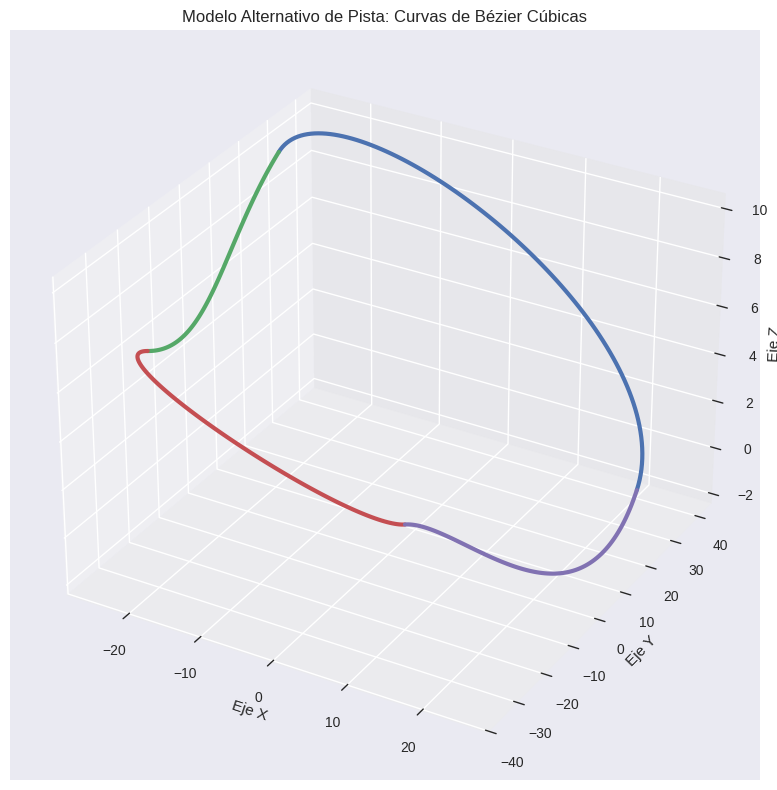

In [6]:
############################ AGREGUE SU IMPLEMENTACIÓN EN CÓDIGO EN ESTA PARTE ###########################

print("Modelo Matemático Alternativo desarrollado con IA")
par = np.linspace(0,1,100)

# Puntos para los segmentos de la pista.
points = [
    {
        "x": [25,25,-25,-25],
        "y": [25,45,45,25],
        "z": [0,5,12,10],
    },
    {
        "x": [-25, -25, -25, -25],
        "y": [25, 5, 0, -20],
        "z": [10, 8, 4, 6],
    },
    {
        "x": [-25, -25, 10, 10],
        "y": [-20, -40, -40, -20],
        "z": [6, 8, 4, 2],
    },
    {
        "x": [10, 10, 25, 25],
        "y": [-20, 0, 5, 25],
        "z": [2, 0, -5, 0],
    },
]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection="3d")

for point in points:
  x0, x1, x2, x3 = point["x"]
  y0, y1, y2, y3 = point["y"]
  z0, z1, z2, z3 = point["z"]

  # Ecuaciones paramétricas vectorizadas
  bx = (
    (1 - par) ** 3 * x0
    + 3 * (1 - par) ** 2 * par * x1
    + 3 * (1 - par) * par**2 * x2
    + par**3 * x3
  )
  by = (
    (1 - par) ** 3 * y0
    + 3 * (1 - par) ** 2 * par * y1
    + 3 * (1 - par) * par**2 * y2
    + par**3 * y3
  )
  bz = (
    (1 - par) ** 3 * z0
    + 3 * (1 - par) ** 2 * par * z1
    + 3 * (1 - par) * par**2 * z2
    + par**3 * z3
  )
  ax.plot(bx, by, bz, linewidth=3)


ax.set_title(
    "Modelo Alternativo de Pista: Curvas de Bézier Cúbicas",
    fontsize=12
)
ax.set_xlabel("Eje X")
ax.set_ylabel("Eje Y")
ax.set_zlabel("Eje Z")

plt.tight_layout()
plt.show()
############################################

$6.$ Compare los dos modelos: el suyo y el alternativo generado por la IA en el inciso anterior. Discuta las ventajas y desventajas de cada uno.

In [7]:
############################ AGREGUE SU IMPLEMENTACIÓN EN CÓDIGO EN ESTA PARTE ###########################
print("Comparativa entre el modelo original y el modelo alternativo\n")
print("***** MODELO ORIGINAL *****\n")
print("Pros: \n")
print("- Cada segmento tiene una interpretación clara, como el segmento 1 que se puede ver claro que es un segmento de hélice.\n")
print("- Al tener senos, cosenos y expresiones lineales y cuadraticas, es fácil hacer los cálculos necesarios para las derivadas, \n")
print("intersecciones, longitud de arco y demás.\n")
print("Cons: \n")
print("- Los segmentos de la pista son muy rigidos, entonces el cambiar la estructura requiere cambiar fundamentalmente la recta en si. \n")
print("***** MODELO ALTERNATIVO *****\n")
print("Pros: \n")
print("-  Hay más libertad para ir dibujando la trayectoria tramo a tramo porque simplemente se pueden alterar los puntos de control. \n")
print("- Se abre a más posibilidades (de complejidad razonable) en comparación al primer modelo donde estábamos limitados por hélices, \n")
print("parábolas, circunferencias, etc.  \n")
print("- Como hay pequeños puntos donde los segmentos se comparten con otros, la trayectoria se cierra de manera más natural.\n")
print("Cons: \n")
print("- Precisamente para hacer que las transiciones entre segmentos sean más naturales hay que asegurarse que las coordenadas que componen \n")
print("dicha trayectoria deben ser iguales para el inicio y final de 2 segmentos, independientemente de las ecuaciones que los conformen. \n")
print("- Dependiendo de la curva que se analice para un segmento cualquiera, la integral relacionada a su longitud de arco puede no tener \n")
print("solución elemental, por lo que se deberían utilizar métodos numéricos.\n")




############################################

Comparativa entre el modelo original y el modelo alternativo

***** MODELO ORIGINAL *****

Pros: 

- Cada segmento tiene una interpretación clara, como el segmento 1 que se puede ver claro que es un segmento de hélice.

- Al tener senos, cosenos y expresiones lineales y cuadraticas, es fácil hacer los cálculos necesarios para las derivadas, 

intersecciones, longitud de arco y demás.

Cons: 

- Los segmentos de la pista son muy rigidos, entonces el cambiar la estructura requiere cambiar fundamentalmente la recta en si. 

***** MODELO ALTERNATIVO *****

Pros: 

-  Hay más libertad para ir dibujando la trayectoria tramo a tramo porque simplemente se pueden alterar los puntos de control. 

- Se abre a más posibilidades (de complejidad razonable) en comparación al primer modelo donde estábamos limitados por hélices, 

parábolas, circunferencias, etc.  

- Como hay pequeños puntos donde los segmentos se comparten con otros, la trayectoria se cierra de manera más natural.

Cons: 

- Precisam

$7.$ Con ayuda de la IA y ambos modelos matemáticos, responda:

- ¿Cómo comprobar en Python que la longitud de arco es coherente con la escala de la pista en ambos modelos?

In [40]:
########################################################################################################
#  ####### AGREGUE SU IMPLEMENTACIÓN  EN CÓDIGO PARA JUSTIFICAR SU RESPUESTA EN ESTA PARTE #############
# ##############

def bezier_expr(p0, p1, p2, p3):
  return (1 - t) ** 3 * p0 + 3 * (1 - t) ** 2 * t * p1 + 3 * (1 - t) * t**2 * p2 + t**3 * p3


curvas_bezier_def = {
    'b1': {
        'x': bezier_expr(25, 25, -25, -25),
        'y': bezier_expr(25, 45, 45, 25),
        'z': bezier_expr(0, 5, 12, 10),
        'tmin': 0,
        'tmax': 1,
        'tSteps': 100,
        'color': 'red',
    },
    'b2': {
        'x': bezier_expr(-25, -25, -25, -25),
        'y': bezier_expr(25, 5, 0, -20),
        'z': bezier_expr(10, 8, 4, 6),
        'tmin': 0,
        'tmax': 1,
        'tSteps': 100,
        'color': 'blue',
    },
    'b3': {
        'x': bezier_expr(-25, -25, 10, 10),
        'y': bezier_expr(-20, -40, -40, -20),
        'z': bezier_expr(6, 8, 4, 2),
        'tmin': 0,
        'tmax': 1,
        'tSteps': 100,
        'color': 'darkgreen',
    },
    'b4': {
        'x': bezier_expr(10, 10, 25, 25),
        'y': bezier_expr(-20, 0, 5, 25),
        'z': bezier_expr(2, 0, -5, 0),
        'tmin': 0,
        'tmax': 1,
        'tSteps': 100,
        'color': 'purple',
    },
}

def calcular_modelo(diccionario, nombre_modelo):
  instancias = []
  longitud_total = 0.0

  print(f'*** {nombre_modelo} ***')
  for clave, data in diccionario.items():
    curva = CurvaParametrica(
        nombre=clave,
        x_expr=data['x'],
        y_expr=data['y'],
        z_expr=data['z'],
        tmin=data['tmin'],
        tmax=data['tmax'],
        tSteps=data['tSteps'],
        color=data['color'],
    )

    longitud, exacta = curva.longitud_arco()
    longitud_total += longitud
    instancias.append(curva)

    print(
        f"Tramo {clave}: Longitud = {longitud:.2f} u"

    )

  print(f'Longitud Total: {longitud_total:.2f} unidades\n')
  return longitud_total, instancias


# Calculo de distancias
L_original, instancias_orig = calcular_modelo(curvas_def, 'MODELO ORIGINAL')
L_bezier, instancias_bezier = calcular_modelo(
    curvas_bezier_def, 'MODELO BEZIER'
)

# Comparativa
diferencia = abs(L_original - L_bezier)
porcentaje_variacion = (diferencia / L_original) * 100

print('****** EVALUACION DE COHERENCIA EN ESCALA ******')
print(f'Diferencia: {diferencia:.2f} unidades')
print(f'Variación respecto al original: {porcentaje_variacion:.2f}%')

if porcentaje_variacion < 5:
  print('El modelo alternativo es coherente.')
else:
  print('Existe discrepancia.')
print()





############################################

*** MODELO ORIGINAL ***
Tramo r1: Longitud = 79.17 u
Tramo r2: Longitud = 46.52 u
Tramo r3: Longitud = 91.65 u
Tramo r4: Longitud = 19.10 u
Tramo r5: Longitud = 16.16 u
Longitud Total: 252.60 unidades

*** MODELO BEZIER ***
Tramo b1: Longitud = 65.49 u
Tramo b2: Longitud = 45.35 u
Tramo b3: Longitud = 51.92 u
Tramo b4: Longitud = 48.64 u
Longitud Total: 211.41 unidades

****** EVALUACION DE COHERENCIA EN ESCALA ******
Diferencia: 41.19 unidades
Variación respecto al original: 16.31%
Existe discrepancia.



- ¿Qué aplicación tiene el esquema TNB en este problema?

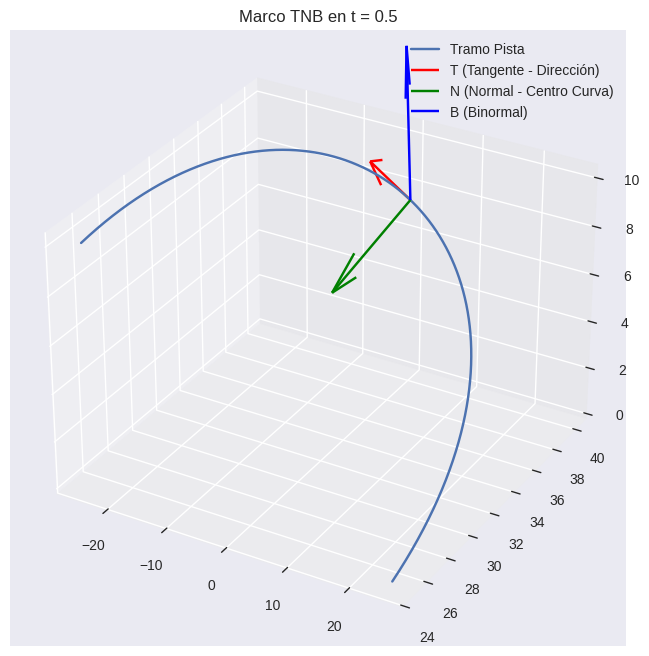

In [43]:
########################################################################################################
#  ####### AGREGUE SU IMPLEMENTACIÓN  EN CÓDIGO PARA JUSTIFICAR SU RESPUESTA EN ESTA PARTE #############
# ##############

'''
Con el esquema TNB (Tangente, Normal y Binormal) podemos saber hacia donde apunta la dirección de movimiento(T), en que direccion
se curva (N) y el eje de rotacion de la funcion que estamos analizando.
'''
def marco_tnb_evaluar(self, t_val):

  v_num = np.array(
      [self._fvx(t_val), self._fvy(t_val), self._fvz(t_val)], dtype=float
  )
  fax = sp.lambdify(t, self.a[0], 'numpy')
  fay = sp.lambdify(t, self.a[1], 'numpy')
  faz = sp.lambdify(t, self.a[2], 'numpy')
  a_num = np.array([fax(t_val), fay(t_val), faz(t_val)], dtype=float)

  # Vector Tangente T
  norma_v = np.linalg.norm(v_num)
  if norma_v == 0:
    return None
  T = v_num / norma_v

  # Vector Binormal B (v x a / |v x a|)
  v_cross_a = np.cross(v_num, a_num)
  norma_cross = np.linalg.norm(v_cross_a)
  if norma_cross == 0:
    B = np.array([0.0, 0.0, 1.0])
  else:
    B = v_cross_a / norma_cross

  # Vector Normal N (B x T)
  N = np.cross(B, T)
  N = N / np.linalg.norm(N)

  # tau = (v x a) . a' / |v x a|^2
  torsion = self.a.diff(t)  # r'''(t)
  fjx = sp.lambdify(t, torsion[0], 'numpy')
  fjy = sp.lambdify(t, torsion[1], 'numpy')
  fjz = sp.lambdify(t, torsion[2], 'numpy')
  torsion_num = np.array([fjx(t_val), fjy(t_val), fjz(t_val)], dtype=float)

  tau = (
      np.dot(v_cross_a, torsion_num) / (norma_cross**2) if norma_cross != 0 else 0
  )

  return {'T': T, 'N': N, 'B': B, 'tau': tau}

tramo_ejemplo = instancias_bezier[0]

t_eval = 0.5
tnb = marco_tnb_evaluar(tramo_ejemplo, t_eval)

px = tramo_ejemplo._fx(t_eval)
py = tramo_ejemplo._fy(t_eval)
pz = tramo_ejemplo._fz(t_eval)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

# Dibujar la curva
t_vals = np.linspace(0, 1, 100)
ax.plot(
    tramo_ejemplo._fx(t_vals),
    tramo_ejemplo._fy(t_vals),
    tramo_ejemplo._fz(t_vals),
    label='Tramo Pista',
)

# Escala para que los vectores se puedan ver bien
esc = 7.0
ax.quiver(
    px,
    py,
    pz,
    tnb['T'][0],
    tnb['T'][1],
    tnb['T'][2],
    color='r',
    length=esc,
    label='T (Tangente - Dirección)',
)
ax.quiver(
    px,
    py,
    pz,
    tnb['N'][0],
    tnb['N'][1],
    tnb['N'][2],
    color='g',
    length=esc,
    label='N (Normal - Centro Curva)',
)
ax.quiver(
    px,
    py,
    pz,
    tnb['B'][0],
    tnb['B'][1],
    tnb['B'][2],
    color='b',
    length=esc,
    label='B (Binormal)',
)

ax.set_title(f'Marco TNB en t = {t_eval}')
ax.legend()
plt.show()





############################################

- ¿Cómo interpretaría la curvatura máxima en términos de dificultad de conducción?

In [44]:
########################################################################################################
#  ####### AGREGUE SU IMPLEMENTACIÓN  EN CÓDIGO PARA JUSTIFICAR SU RESPUESTA EN ESTA PARTE #############
# ##############

'''
En el punto donde la curvatura es máxima y en los puntos aledaños, el carrito debe hacer un giro más cerrado para no chocar, por lo que la dificultad de conducción en ese punto es más alta.
'''
print('***** INTERPRETACION DE CURVATURA MAXIMA *****')


picos_bezier = []
for curva in instancias_bezier:
  valores_t = np.linspace(curva.tmin, curva.tmax, curva.tSteps)

  valores_curvatura = curva._fcurvatura(valores_t)

  # Encontrar el índice donde la curvatura es máxima en este tramo
  indice_maximo = np.argmax(valores_curvatura)

  t_max = valores_t[indice_maximo]
  kappa_max = valores_curvatura[indice_maximo]
  x_pico = curva._fx(t_max)
  y_pico = curva._fy(t_max)
  z_pico = curva._fz(t_max)

  picos_bezier.append({
      "tramo": curva.nombre,
      "t_max": t_max,
      "kappa_max": kappa_max,
      "coordenadas": (x_pico, y_pico, z_pico),
  })

  print(f"Tramo: {curva.nombre}")
  print(f"Curvatura Máxima (κ_max): {kappa_max:.6f}")
  print(f"parámetro t = {t_max:.4f}")
  print(
      f"P(x, y, z): ({x_pico:.2f}, {y_pico:.2f},"
      f"{z_pico:.2f})\n"
  )

pico_critico = max(picos_bezier, key=lambda p: p["kappa_max"])

print(
    f"Punto de mayor DIFICULTAD: {pico_critico['tramo']} con κ = "
    f"{pico_critico['kappa_max']:.6f}"
)


############################################

***** INTERPRETACION DE CURVATURA MAXIMA *****
Tramo: b1
Curvatura Máxima (κ_max): 0.094741
parámetro t = 0.9394
P(x, y, z): (-24.47, 28.42,10.27)

Tramo: b2
Curvatura Máxima (κ_max): 0.014069
parámetro t = 0.6970
P(x, y, z): (-25.00, -5.12,5.61)

Tramo: b3
Curvatura Máxima (κ_max): 0.077114
parámetro t = 0.1313
P(x, y, z): (-23.35, -26.84,6.50)

Tramo: b4
Curvatura Máxima (κ_max): 0.034430
parámetro t = 0.8182
P(x, y, z): (23.69, 15.40,-1.81)

Punto de mayor DIFICULTAD: b1 con κ = 0.094741


- ¿Cómo modificaría $z(t)$ en ambos modelos de la pista para simular un puente más pronunciado o un túnel más largo?

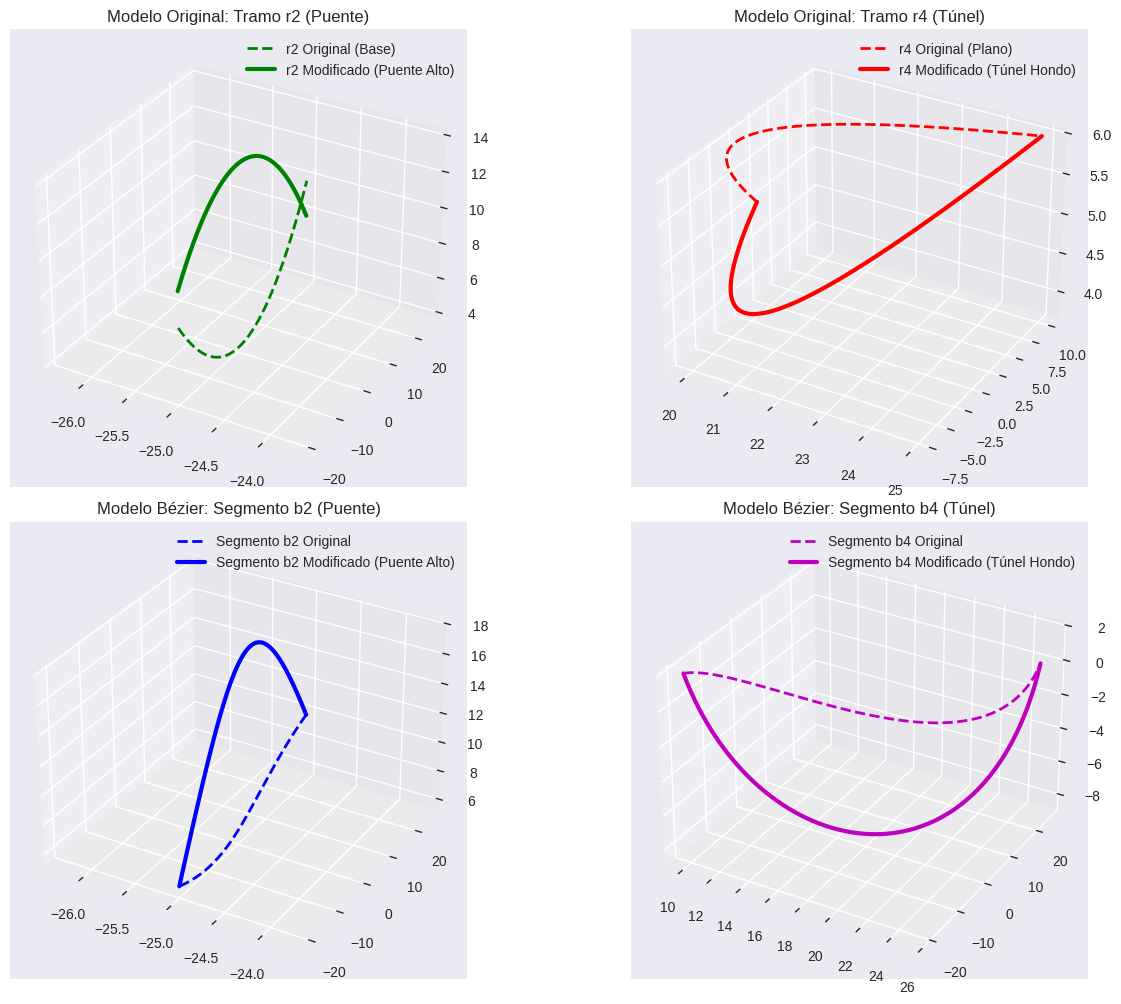

In [37]:
########################################################################################################
#  ####### AGREGUE SU IMPLEMENTACIÓN  EN CÓDIGO PARA JUSTIFICAR SU RESPUESTA EN ESTA PARTE #############
# ##############

r2_original = 0.01 * t**2 - 0.0055556 * t + 3.8889
r2_puente = -0.01 * (t - 25) * (t + 20) + (10 - (2 / 45) * (t + 20))
r4_original = sp.Integer(6)
r4_tunel = 0.03 * (t + 7.5) * (t - 10) + 6

b2_orig_z = bezier_expr(10, 8, 4, 6)
b2_mod_z = bezier_expr(10, 22, 20, 6)
b4_orig_z = bezier_expr(2, 0, -5, 0)
b4_mod_z = bezier_expr(2, -12, -12, 0)
fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(221, projection='3d')
t_r2 = np.linspace(-20, 25, 200)
x_r2 = np.full_like(t_r2, -25)
fz_r2_orig = sp.lambdify(t, r2_original, 'numpy')
fz_r2_mod = sp.lambdify(t, r2_puente, 'numpy')
ax1.plot(
    x_r2, t_r2, fz_r2_orig(t_r2), 'g--', linewidth=2, label='r2 Original (Base)'
)
ax1.plot(
    x_r2,
    t_r2,
    fz_r2_mod(t_r2),
    'g-',
    linewidth=3,
    label='r2 Modificado (Puente Alto)',
)
ax1.set_title('Modelo Original: Tramo r2 (Puente)')
ax1.legend()

ax2 = fig.add_subplot(222, projection='3d')
t_r4 = np.linspace(-7.5, 10, 200)
fx_r4 = 0.04 * t_r4**2 + 0.091429 * t_r4 + 20.00857
fz_r4_orig = sp.lambdify(t, r4_original, 'numpy')
fz_r4_mod = sp.lambdify(t, r4_tunel, 'numpy')
ax2.plot(
    fx_r4,
    t_r4,
    fz_r4_orig(t_r4),
    'r--',
    linewidth=2,
    label='r4 Original (Plano)',
)
ax2.plot(
    fx_r4,
    t_r4,
    fz_r4_mod(t_r4),
    'r-',
    linewidth=3,
    label='r4 Modificado (Túnel Hondo)',
)
ax2.set_title('Modelo Original: Tramo r4 (Túnel)')
ax2.legend()

ax3 = fig.add_subplot(223, projection='3d')
t_b = np.linspace(0, 1, 200)
bx_b2 = sp.lambdify(t, bezier_expr(-25, -25, -25, -25), 'numpy')(t_b)
by_b2 = sp.lambdify(t, bezier_expr(25, 5, 0, -20), 'numpy')(t_b)
bz_b2_orig = sp.lambdify(t, b2_orig_z, 'numpy')(t_b)
bz_b2_mod = sp.lambdify(t, b2_mod_z, 'numpy')(t_b)
ax3.plot(
    bx_b2,
    by_b2,
    bz_b2_orig,
    'b--',
    linewidth=2,
    label='Segmento b2 Original',
)
ax3.plot(
    bx_b2,
    by_b2,
    bz_b2_mod,
    'b-',
    linewidth=3,
    label='Segmento b2 Modificado (Puente Alto)',
)
ax3.set_title('Modelo Bézier: Segmento b2 (Puente)')
ax3.legend()

ax4 = fig.add_subplot(224, projection='3d')
bx_b4 = sp.lambdify(t, bezier_expr(10, 10, 25, 25), 'numpy')(t_b)
by_b4 = sp.lambdify(t, bezier_expr(-20, 0, 5, 25), 'numpy')(t_b)
bz_b4_orig = sp.lambdify(t, b4_orig_z, 'numpy')(t_b)
bz_b4_mod = sp.lambdify(t, b4_mod_z, 'numpy')(t_b)
ax4.plot(
    bx_b4,
    by_b4,
    bz_b4_orig,
    'm--',
    linewidth=2,
    label='Segmento b4 Original',
)
ax4.plot(
    bx_b4,
    by_b4,
    bz_b4_mod,
    'm-',
    linewidth=3,
    label='Segmento b4 Modificado (Túnel Hondo)',
)
ax4.set_title('Modelo Bézier: Segmento b4 (Túnel)')
ax4.legend()

plt.tight_layout()
plt.show()

############################################

- Encuentre la velocidad máxima para que el vehículo no se salga de la pista en los puntos marcados como $A$ y $B$ en la Figura 3.

In [47]:
########################################################################################################
#  ####### AGREGUE SU IMPLEMENTACIÓN  EN CÓDIGO PARA JUSTIFICAR SU RESPUESTA EN ESTA PARTE #############
# ##############


puntosInteres = [
    {
        'punto': 'A (Antes de la rampa)',
        'segmento': 'Segmento 1',
        'px': [25, 25, -25, -25],
        'py': [25, 45, 45, 25],
        'pz': [0, 5, 12, 10],
        'tEval': 0.2,
    },
    {
        'punto': 'B (Despues de la rampa)',
        'segmento': 'Segmento 3',
        'px': [-25, -25, 10, 10],
        'py': [-20, -40, -40, -20],
        'pz': [6, 8, 4, 2],
        'tEval': 0.5,
    },
]
# asumiendo que el dia es soleado en el reino champiñon, habría interacción caucho-asfalto seco
muS = 0.8
g = 9.81

print('***** CÁLCULO DE VELOCIDAD SIN DERRAPE *****\n')
print(f'Parámetros asumidos: coeficiente de fricción = {muS}, g = {g} m/s^2\n')

for item in puntosInteres:
  xE = bezier_expr(*item['px'])
  yE = bezier_expr(*item['py'])
  zE = bezier_expr(*item['pz'])

  # Vector posición, velocidad r'(t) y aceleración r''(t)
  r = sp.Matrix([xE, yE, zE])
  v = r.diff(t)
  a = v.diff(t)

  # kappa = |v x a| / |v|^3
  rapidez = sp.sqrt(sum(comp**2 for comp in v))
  crossProd = v.cross(a)
  normaCross = sp.sqrt(sum(comp**2 for comp in crossProd))
  curvaturaExpr = normaCross / (rapidez**3)

  fCurvatura = sp.lambdify(t, curvaturaExpr, 'numpy')
  kappaVal = float(fCurvatura(item['tEval']))

  radioCur = 1.0 / kappaVal

  # Velocidad máxima física: v_max = sqrt(mu_s * g * R)
  vMaxMS = np.sqrt(muS * g * radioCur)
  vMaxKmh = vMaxMS * 3.6

  print(f"PUNTO {item['punto']}:")
  print(f"Evalua en {item['segmento']} a t = {item['tEval']}")
  print(f'Curvatura (kappa): {kappaVal:.6f} m^-1')
  print(f'Radio de curvatura (R): {radioCur:.2f} m')
  print(f'Velocidad Máxima: {vMaxMS:.2f} m/s ({vMaxKmh:.2f} km/h)\n')


############################################

***** CÁLCULO DE VELOCIDAD SIN DERRAPE *****

Parámetros asumidos: coeficiente de fricción = 0.8, g = 9.81 m/s^2

PUNTO A (Antes de la rampa):
Evalua en Segmento 1 a t = 0.2
Curvatura (kappa): 0.053118 m^-1
Radio de curvatura (R): 18.83 m
Velocidad Máxima: 12.16 m/s (43.76 km/h)

PUNTO B (Despues de la rampa):
Evalua en Segmento 3 a t = 0.5
Curvatura (kappa): 0.043188 m^-1
Radio de curvatura (R): 23.15 m
Velocidad Máxima: 13.48 m/s (48.53 km/h)



**Nota:** *las respuestas a estas preguntas deben redactarse sin apoyo de herramientas de IA, utilizando únicamente su propio análisis y juicio crítico. Puede apoyarse con visualizaciones en Python.*